In [6]:
import rasterio
import numpy as np
from pathlib import Path
from samgeo import SamGeo3
from matplotlib import pyplot as plt


In [7]:
geotiff_path = "/export/sata01/wspace/test_dir/multi/demo/image/ns2_small_rgbn.tif"
# geotiff_path = "/export/sata01/wspace/test_dir/multi/all_rgb_data/test/BC31_RGB_8bit.tif"
# geotiff_path = "/home/valhassa/dev/geo-inference/examples/uc_berkeley.tif"

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 4624, 'height': 2006, 'count': 4, 'crs': CRS.from_wkt('PROJCS["NAD83 / UTM zone 21N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26921"]]'), 'transform': Affine(0.5000424956747448, 0.0, 268294.0366,
       0.0, -0.5000014955132405, 5089862.0582), 'blockxsize': 4624, 'blockysize': 1, 'tiled': False, 'interleave': 'pixel'}


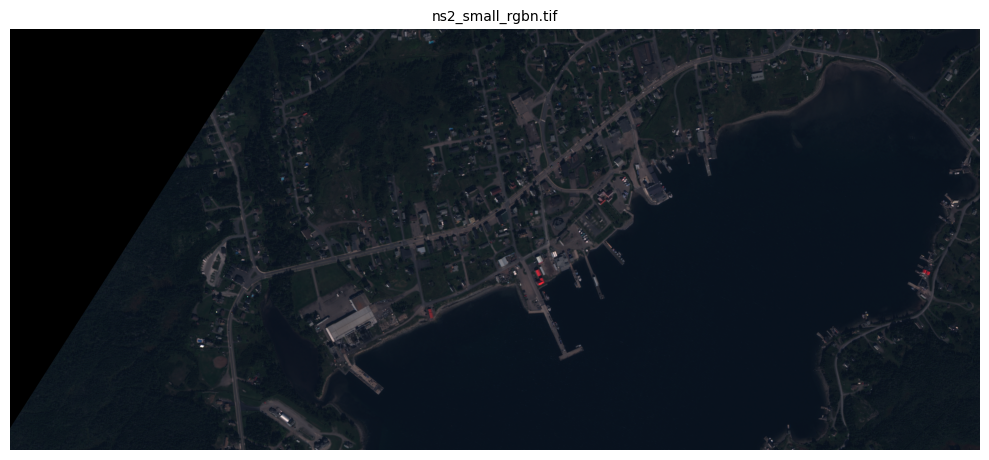

In [8]:
with rasterio.open(geotiff_path) as src:
    print(src.profile)
    arr = src.read()
    n = src.count

if n >= 3:
    rgb = np.transpose(arr[:3], (1, 2, 0))
    if rgb.dtype == np.uint8:
        rgb = rgb.astype(np.float32) / 255.0
    else:
        plo, phi = np.percentile(rgb, (2, 98), axis=(0, 1))
        plo, phi = plo.reshape(1, 1, -1), phi.reshape(1, 1, -1)
        rgb = np.clip((rgb - plo) / (phi - plo + 1e-9), 0, 1)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(rgb)
else:
    band = arr[0].astype(np.float32)
    plo, phi = np.percentile(band, (2, 98))
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(np.clip((band - plo) / (phi - plo + 1e-9), 0, 1), cmap="gray")

ax.set_axis_off()
ax.set_title(Path(geotiff_path).name, fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
BPE_PATH = "/export/sata01/wspace/test_dir/multi/demo/hf/tokenizer/bpe_simple_vocab_16e6.txt.gz"
CHECKPOINT_PATH = "/export/sata01/wspace/test_dir/multi/demo/hf/sam3.pt"
sam3 = SamGeo3(
        backend="meta",
        bpe_path=BPE_PATH,
        checkpoint_path=CHECKPOINT_PATH,
        load_from_HF=CHECKPOINT_PATH is None,
        device="cuda",
    )

Using cuda device and meta backend


In [16]:
sam3.set_image(geotiff_path)
sam3.generate_masks(prompt="forest")
sam3.show_anns()


No objects found. Please try a different prompt.


In [ ]:
tmp_path = Path("./tiled_masks.tif")
sam3.generate_masks_tiled(
        source=str(geotiff_path),
        prompt="building",
        output=str(tmp_path),
        tile_size=1024,
        overlap=128,
        bands=[1, 2, 3],
        unique=True,
        dtype="uint32",   # uint8 caps at 255 instances — use uint32 for safety
    )

Processing image: 4624 x 2006 pixels
Tile size: 1024, Overlap: 128
Total tiles to process: 18 (6 x 3)


Processing tiles:  11%|█         | 2/18 [00:00<00:01, 14.57it/s]

Processing tiles:  28%|██▊       | 5/18 [00:00<00:00, 20.62it/s]

Processing tiles:  44%|████▍     | 8/18 [00:00<00:00, 22.83it/s]

Processing tiles:  61%|██████    | 11/18 [00:00<00:00, 23.96it/s]

Processing tiles:  78%|███████▊  | 14/18 [00:00<00:00, 24.54it/s]

Processing tiles:  94%|█████████▍| 17/18 [00:00<00:00, 24.88it/s]

Processing tiles: 100%|██████████| 18/18 [00:00<00:00, 22.90it/s]


Saved mask to tiled_masks.tif
Total objects found: 0


'tiled_masks.tif'

{'driver': 'GTiff', 'dtype': 'uint32', 'nodata': None, 'width': 4624, 'height': 2006, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / UTM zone 21N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26921"]]'), 'transform': Affine(0.5000424956747448, 0.0, 268294.0366,
       0.0, -0.5000014955132405, 5089862.0582), 'blockxsize': 4624, 'blockysize': 1, 'tiled': False, 'compress': 'deflate', 'interleave': 'band'}


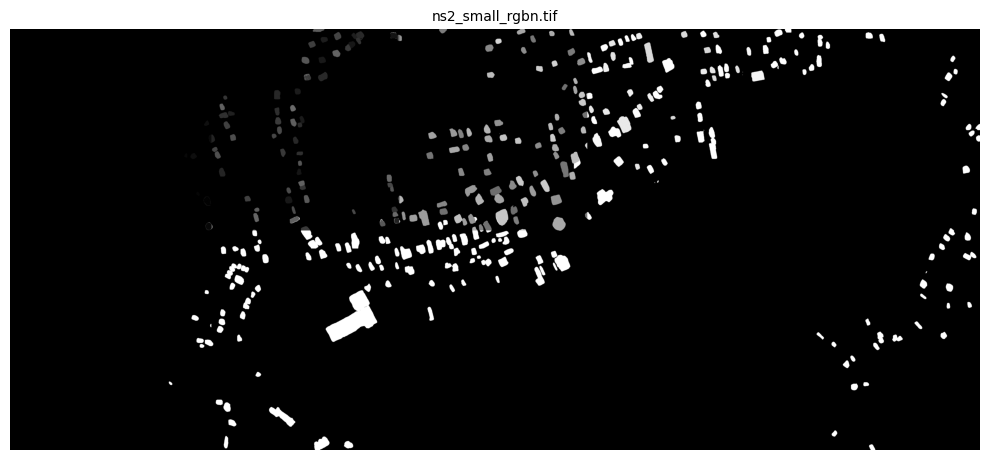

In [18]:
with rasterio.open(tmp_path) as src:
    print(src.profile)
    arr = src.read()
    n = src.count

if n >= 3:
    rgb = np.transpose(arr[:3], (1, 2, 0))
    if rgb.dtype == np.uint8:
        rgb = rgb.astype(np.float32) / 255.0
    else:
        plo, phi = np.percentile(rgb, (2, 98), axis=(0, 1))
        plo, phi = plo.reshape(1, 1, -1), phi.reshape(1, 1, -1)
        rgb = np.clip((rgb - plo) / (phi - plo + 1e-9), 0, 1)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(rgb)
else:
    band = arr[0].astype(np.float32)
    plo, phi = np.percentile(band, (2, 98))
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(np.clip((band - plo) / (phi - plo + 1e-9), 0, 1), cmap="gray")

ax.set_axis_off()
ax.set_title(Path(geotiff_path).name, fontsize=10)
plt.tight_layout()
plt.show()